# Classificacao de Tumores Cerebrais por MRI: Modelo Classico vs Hibrido Quantico

Este notebook implementa e compara dois classificadores binarios (Benigno vs Maligno) para imagens de ressonancia magnetica cerebral:

1. **ClassicalResNet18**: Uma ResNet-18 pre-treinada (ImageNet) com a camada final substituida por uma cabeca de classificacao classica.
2. **HybridResNet18**: A mesma ResNet-18 como extratora de features, mas com um **Circuito Quantico Variacional (VQC)** de 4 qubits no lugar da cabeca classica.

O objetivo e avaliar se o processamento quantico oferece alguma vantagem na classificacao de imagens medicas em relacao ao modelo puramente classico.

### Metodologia
- **Dados**: Dataset de MRI (SartajBhuvaji/Brain-Tumor-Classification) dividido em 70% Treino / 15% Validacao / 15% Teste Cego.
- **Hiperparametros**: Carregados a partir dos resultados de otimizacao com Optuna (se disponiveis) ou valores padrao de backup.
- **Treinamento**: 20 epocas com otimizador Adam, ReduceLROnPlateau e checkpointing do melhor modelo.
- **Avaliacao**: Inferencia em dados nunca vistos (Blind Test) + Matrizes de Confusao.

In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import sys
import os
import json
import torch
import numpy as np

# Adiciona o diretorio raiz ao path para importar os modulos do projeto
sys.path.append(os.path.abspath('../../../'))

from qml.group_works.group_01.loaders.mri_loader import get_dataloaders
from qml.group_works.group_01.models.hybrid_resnet import HybridResNet18
from qml.group_works.group_01.models.classical_resnet import ClassicalResNet18
from qml.group_works.group_01.trainer.training_loop import train_model, test_model
from qml.group_works.group_01.evaluation.metrics import plot_comparison, plot_confusion_matrix

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando dispositivo: {device}')

# Define pasta de saida para os resultados do notebook
output_notebook_dir = '../../../data/group_works/group_01/notebook/'
os.makedirs(output_notebook_dir, exist_ok=True)

Usando dispositivo: cuda


## 1. Carregamento dos Dados

O dataset e composto por imagens de ressonancia magnetica cerebral, reclassificadas em duas categorias:
- **Benigno**: Tumores do tipo Meningioma (menos agressivos).
- **Maligno**: Tumores do tipo Glioma e Pituitario (mais agressivos).

As imagens passam pelo seguinte pre-processamento:
1. Redimensionamento para **224x224 pixels** (padrao da ResNet).
2. Normalizacao dos canais RGB com media e desvio padrao do ImageNet.

A divisao segue o padrao cientifico **70/15/15**:
- **Treino (70%)**: Usado para ajustar os pesos do modelo.
- **Validacao (15%)**: Usado para monitorar overfitting e salvar o melhor checkpoint.
- **Teste Cego (15%)**: Dados 100% ineditos, usados apenas na inferencia final.

In [13]:
train_loader, val_loader, test_loader = get_dataloaders(batch_size=8)
print(f'Treino: {len(train_loader.dataset)} amostras')
print(f'Validacao: {len(val_loader.dataset)} amostras')
print(f'Teste Cego: {len(test_loader.dataset)} amostras')

Dataset já encontrado em ../../../data/group_works/group_01/mri_dataset. Pulando o download.
Treino: 1153 amostras
Validacao: 247 amostras
Teste Cego: 248 amostras


## 2. Hiperparametros Otimizados

Os hiperparametros foram encontrados previamente pelo **Optuna** (script `run_optimization.py`), que testou 10 combinacoes diferentes para cada modelo.

Os parametros otimizados sao:
- **Learning Rate (lr)**: Taxa de aprendizado do otimizador Adam. Controla o tamanho do passo que o modelo da a cada atualizacao de pesos.
- **Weight Decay**: Penalidade L2 aplicada aos pesos. Funciona como regularizacao para evitar overfitting.
- **Quantum Depth (q_depth)** *(somente hibrido)*: Profundidade do circuito quantico (numero de camadas de portas quanticas).

Caso a otimizacao nao tenha sido executada ainda, o notebook utiliza **valores padrao de backup** que garantem um treino funcional.

In [14]:
data_path = '../../../data/group_works/group_01/'

# Parametros padrao de backup (usados caso a otimizacao nao tenha rodado)
DEFAULT_HYBRID = {'lr': 0.0004, 'weight_decay': 1e-4, 'q_depth': 1}
DEFAULT_CLASSICAL = {'lr': 0.0004, 'weight_decay': 1e-4}

def load_best_params(filename, defaults):
    """Carrega parametros otimizados do JSON ou retorna os valores padrao."""
    path = os.path.join(data_path, filename)
    if os.path.exists(path):
        with open(path, 'r') as f:
            params = json.load(f)
            print(f'  Carregados de: {filename}')
            return params
    print(f'  Arquivo {filename} nao encontrado. Usando parametros padrao.')
    return defaults

print('Parametros do modelo hibrido:')
best_hybrid = load_best_params('best_params_hybrid.json', DEFAULT_HYBRID)
print(f'  {best_hybrid}')

print('\nParametros do modelo classico:')
best_classical = load_best_params('best_params_classical.json', DEFAULT_CLASSICAL)
print(f'  {best_classical}')

Parametros do modelo hibrido:
  Carregados de: best_params_hybrid.json
  {'lr': 0.00021429566588818236, 'weight_decay': 2.227472212228259e-06, 'q_depth': 3}

Parametros do modelo classico:
  Carregados de: best_params_classical.json
  {'lr': 0.0018702905736676851, 'weight_decay': 1.0428929566416174e-06}


## 3. Arquitetura dos Modelos

### 3.1. Modelo Classico (ClassicalResNet18)

A ResNet-18 e uma rede neural convolucional profunda com 18 camadas, pre-treinada em milhoes de imagens do ImageNet. Ela ja aprendeu a reconhecer bordas, texturas, formas e padroes visuais complexos.

No nosso caso, fazemos **Transfer Learning**:
1. **Backbone congelado**: Todas as camadas convolucionais da ResNet-18 sao congeladas (`requires_grad = False`). Isso significa que elas NAO sao treinadas, apenas reutilizamos a inteligencia visual ja aprendida.
2. **Cabeca de classificacao**: A camada final original (que classificava 1000 categorias do ImageNet) e substituida por uma sequencia de:
   - `Linear(512 -> 4)`: Reduz as 512 features extraidas para 4 valores (mesmo gargalo do modelo hibrido, para comparacao justa).
   - `ReLU()`: Funcao de ativacao nao-linear.
   - `Linear(4 -> 2)`: Classifica em 2 classes (Benigno ou Maligno).

### 3.2. Modelo Hibrido (HybridResNet18)

O modelo hibrido combina a extracao de features classica da ResNet-18 com um **Circuito Quantico Variacional (VQC)** implementado em PennyLane.

O fluxo de dados e:
1. **Backbone ResNet-18 (congelado)**: Extrai 512 features da imagem.
2. **Camada de Dressing (classica)**: `Linear(512 -> 4)` comprime as features para 4 valores reais. Esses 4 valores serao os angulos de rotacao dos qubits.
3. **Circuito Quantico (VQC)**:
   - **Encoding (AngleEmbedding)**: Insere os 4 valores classicos em 4 qubits como angulos de rotacao.
   - **Ansatz (StronglyEntanglingLayers)**: Aplica portas quanticas parametrizadas que criam emaranhamento entre os qubits. A profundidade (`q_depth`) controla quantas camadas de portas sao aplicadas.
   - **Medicao (PauliZ)**: Mede o valor esperado do operador Pauli-Z em cada qubit, produzindo 4 valores reais de saida.
4. **Classificacao final (classica)**: `Linear(4 -> 2)` transforma as 4 medicoes quanticas nos logits das 2 classes.

### 3.3. Diferenciacao Automatica Quantica

Para treinar os parametros quanticos junto com os classicos (end-to-end), utilizamos o metodo **Adjoint Differentiation**. Ele e o equivalente quantico do Backpropagation: explora a reversibilidade das portas quanticas para calcular os gradientes de todos os parametros em uma unica passagem, de forma muito mais rapida que o metodo Parameter-Shift Rule (PSA).

## 4. Treinamento Final (5 epocas)

Cada modelo e treinado por 5 epocas utilizando:
- **Otimizador Adam**: Combina momentum e taxas de aprendizado adaptativas por parametro.
- **CrossEntropyLoss**: Funcao de perda padrao para classificacao.
- **ReduceLROnPlateau**: Se a acuracia de validacao estagnar por 2 epocas, o learning rate e reduzido pela metade.
- **Checkpointing**: Salva automaticamente o estado do modelo na epoca com a melhor acuracia de validacao.

O metodo `model.train()` ativa camadas como Dropout e BatchNorm no modo de aprendizado. O metodo `model.eval()` as desativa para a fase de validacao, garantindo resultados deterministicos.

In [15]:
print('Treinando Modelo Hibrido Otimizado')
q_depth = best_hybrid.get('q_depth', DEFAULT_HYBRID['q_depth'])
lr_h = best_hybrid.get('lr', DEFAULT_HYBRID['lr'])
wd_h = best_hybrid.get('weight_decay', DEFAULT_HYBRID['weight_decay'])

print(f'  lr={lr_h}, weight_decay={wd_h}, q_depth={q_depth}')

hybrid_model = HybridResNet18(num_classes=2, n_qubits=4, q_depth=q_depth)
hybrid_history = train_model(
    model=hybrid_model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    model_name='Hybrid_Notebook',
    epochs=5,
    lr=lr_h,
    weight_decay=wd_h,
    device=device,
    output_dir=output_notebook_dir
)

/mnt/c/UFRJ/Mestrado/2026.1/Aprendizado de Máquina Quântico/pee-886-2026-01/.qml-env/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/c/UFRJ/Mestrado/2026.1/Aprendizado de Máquina Quântico/pee-886-2026-01/.qml-env/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Treinando Modelo Hibrido Otimizado
  lr=0.00021429566588818236, weight_decay=2.227472212228259e-06, q_depth=3


Treinando [Hybrid_Notebook]: 100%|██████████| 145/145 [00:36<00:00,  3.95it/s]


Época 1/5 | Treino Acc: 0.5169 | Valid Acc: 0.5020
Novo melhor modelo salvo: 0.5020


Treinando [Hybrid_Notebook]: 100%|██████████| 145/145 [00:36<00:00,  3.94it/s]


...

Época 3/5 | Treino Acc: 0.7702 | Valid Acc: 0.8381
Novo melhor modelo salvo: 0.8381


Treinando [Hybrid_Notebook]: 100%|██████████| 145/145 [00:37<00:00,  3.85it/s]


Época 4/5 | Treino Acc: 0.8101 | Valid Acc: 0.8502
Novo melhor modelo salvo: 0.8502


Treinando [Hybrid_Notebook]: 100%|██████████| 145/145 [00:37<00:00,  3.86it/s]
                                                          

Época 5/5 | Treino Acc: 0.8083 | Valid Acc: 0.8421


In [16]:
print('Treinando Modelo Classico Otimizado')
lr_c = best_classical.get('lr', DEFAULT_CLASSICAL['lr'])
wd_c = best_classical.get('weight_decay', DEFAULT_CLASSICAL['weight_decay'])

print(f'  lr={lr_c}, weight_decay={wd_c}')

classical_model = ClassicalResNet18(num_classes=2)
classical_history = train_model(
    model=classical_model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    model_name='Classical_Notebook',
    epochs=5,
    lr=lr_c,
    weight_decay=wd_c,
    device=device,
    output_dir=output_notebook_dir
)

Treinando Modelo Classico Otimizado
  lr=0.0018702905736676851, weight_decay=1.0428929566416174e-06


Treinando [Classical_Notebook]: 100%|██████████| 145/145 [00:11<00:00, 12.99it/s]


Época 1/5 | Treino Acc: 0.7459 | Valid Acc: 0.8462
Novo melhor modelo salvo: 0.8462


Treinando [Classical_Notebook]: 100%|██████████| 145/145 [00:11<00:00, 12.40it/s]


Época 2/5 | Treino Acc: 0.8023 | Valid Acc: 0.8300


...

Época 3/5 | Treino Acc: 0.8049 | Valid Acc: 0.8421


Treinando [Classical_Notebook]: 100%|██████████| 145/145 [00:11<00:00, 13.08it/s]


Época 4/5 | Treino Acc: 0.8395 | Valid Acc: 0.8583
Novo melhor modelo salvo: 0.8583


Treinando [Classical_Notebook]: 100%|██████████| 145/145 [00:11<00:00, 12.94it/s]


Época 5/5 | Treino Acc: 0.8378 | Valid Acc: 0.8704
Novo melhor modelo salvo: 0.8704


## 5. Inferencia em Teste Cego (Blind Test)

Nesta etapa avaliamos a capacidade de generalizacao real dos modelos. As imagens do conjunto de teste **nunca foram vistas** durante o treinamento ou a validacao, simulando um cenario clinico real onde o modelo recebe um exame novo.

A funcao `test_model()` retorna:
- A **acuracia** global (proporcao de acertos).
- As **predicoes** do modelo para cada imagem.
- Os **rotulos reais** (gabarito) de cada imagem.

Com as predicoes e os rotulos, podemos calcular o **Ganho Quantico** (diferenca percentual entre o hibrido e o classico).

In [17]:
print('='*40)
print('Resultados finais no teste cego')
print('='*40)

print('\nHibrido')
acc_h, preds_h, true_h = test_model(hybrid_model, test_loader, device=device)

print('\nClassico')
acc_c, preds_c, true_c = test_model(classical_model, test_loader, device=device)

print('\n' + '='*40)
if acc_c > 0:
    ganho = ((acc_h - acc_c) / acc_c * 100)
    print(f'Ganho Quantico: {ganho:+.2f}%')
print('='*40)

# Salva resumo em txt
with open(os.path.join(output_notebook_dir, 'notebook_summary.txt'), 'w') as f:
    f.write(f'Acuracia Hibrido: {acc_h:.4f}\n')
    f.write(f'Acuracia Classico: {acc_c:.4f}\n')
    f.write(f'Hiperparametros Hibrido: {best_hybrid}\n')
    f.write(f'Hiperparametros Classico: {best_classical}\n')

Resultados finais no teste cego

Hibrido
Iniciando inferência final (Blind Test)


Inferencia Final: 100%|██████████| 31/31 [00:04<00:00,  7.25it/s]


Acuracia no teste cego: 0.8468

Classico
Iniciando inferência final (Blind Test)


Inferencia Final: 100%|██████████| 31/31 [00:02<00:00, 13.25it/s]

Acuracia no teste cego: 0.8669

Ganho Quantico: -2.33%


## 6. Visualizacao dos Resultados

### 6.1. Curvas de Treinamento
O grafico comparativo mostra a evolucao da **Perda (Loss)** e da **Acuracia** ao longo das epocas para ambos os modelos.
- Se a curva de treino desce mas a de validacao sobe, isso indica **overfitting** (o modelo decorou os dados de treino).
- O ideal e que ambas as curvas descem juntas e se estabilizem.

### 6.2. Matrizes de Confusao
A matriz de confusao mostra exatamente onde o modelo acerta e erra:
- **Verdadeiro Positivo (VP)**: Maligno classificado corretamente como Maligno.
- **Verdadeiro Negativo (VN)**: Benigno classificado corretamente como Benigno.
- **Falso Positivo (FP)**: Benigno classificado erroneamente como Maligno.
- **Falso Negativo (FN)**: Maligno classificado erroneamente como Benigno (o erro mais grave em contexto clinico).

Curvas de Treinamento
Gráfico comparativo salvo com sucesso em: ../../../data/group_works/group_01/notebook/comparacao_modelos.png


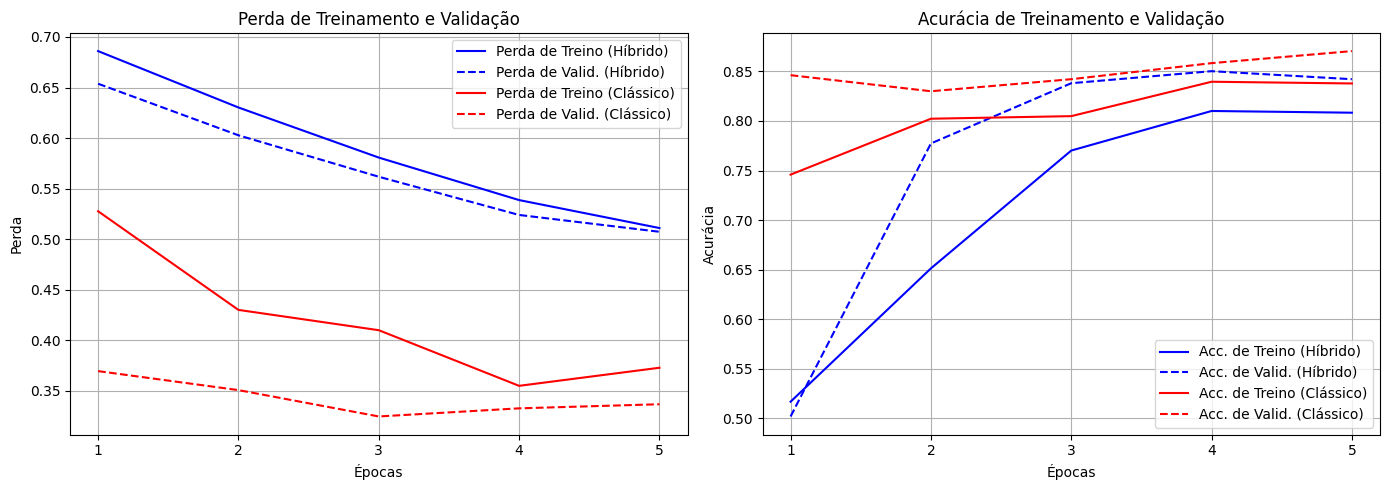

In [18]:
print('Curvas de Treinamento')
plot_comparison(hybrid_history, classical_history, output_dir=output_notebook_dir)

Matriz de Confusao: Hibrido


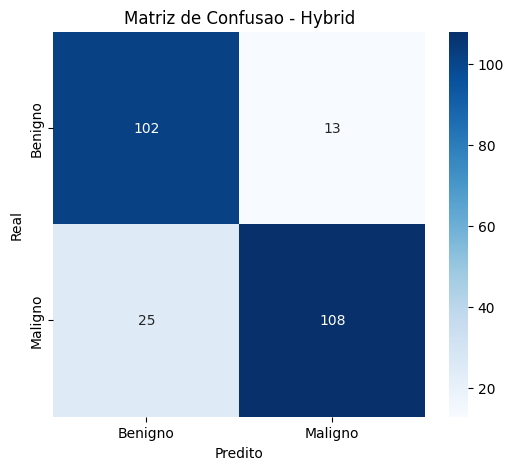

In [19]:
print('Matriz de Confusao: Hibrido')
plot_confusion_matrix(true_h, preds_h, 'Hybrid', output_notebook_dir)

Matriz de Confusao: Classico


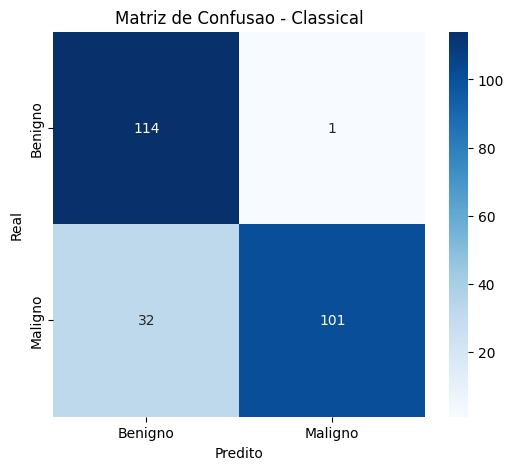

In [20]:
print('Matriz de Confusao: Classico')
plot_confusion_matrix(true_c, preds_c, 'Classical', output_notebook_dir)